In [1]:
#Libraries
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats


In [2]:
#Loading the dataset
df = pd.read_csv(
    "../data/processed/crop_production_clean.csv"
)

df.head()

,Area,crop,year,Area_Harvested_ha,Production_tonnes,Yield_kg_per_ha
0,Ghana,Cassava,1961,140000.0,1050000.0,7500.0
1,Ghana,Maize,1961,237000.0,226000.0,953.6
2,Ghana,Rice,1961,27518.0,30400.0,1104.7
3,Ghana,Yams,1961,150000.0,1100000.0,7333.3
4,Ghana,Cassava,1962,140000.0,1050000.0,7500.0


In [3]:
df.describe()

,year,Area_Harvested_ha,Production_tonnes,Yield_kg_per_ha
count,256.000000,2.560000e+02,2.560000e+02,256.000000
mean,1992.500000,3.933327e+05,3.207099e+06,6578.093359
std,18.509139,3.194860e+05,5.158558e+06,6120.817802
min,1961.000000,2.751800e+04,3.040000e+04,430.000000
25%,1976.750000,1.355292e+05,3.815000e+05,1492.475000
50%,1992.500000,2.585000e+05,1.148000e+06,4401.100000
75%,2008.250000,5.828552e+05,3.250710e+06,11254.375000
max,2024.000000,1.368623e+06,2.791778e+07,25865.000000


In [22]:
os.makedirs("../figures/eda", exist_ok=True)
fig_path = r"C:\Users\hp\Desktop\FOOD PRODUCTION PROJECT\reports\figures"

In [20]:
avg_production = (
    df.groupby("crop")["Production_tonnes"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_production)

crop
Cassava    8.098102e+06
Yams       3.343875e+06
Maize      1.086722e+06
Rice       2.996956e+05
Name: Production_tonnes, dtype: float64


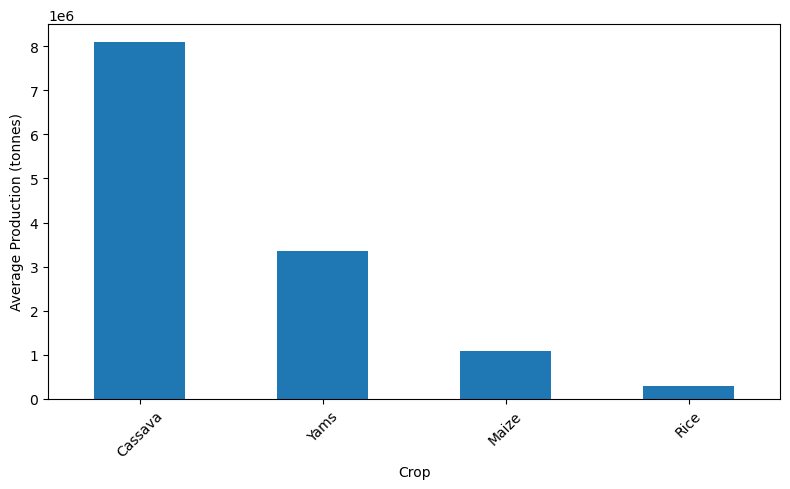

In [24]:
plt.figure(figsize=(8,5))

avg_production.plot(
    kind="bar"
)

plt.title("")
plt.xlabel("Crop")
plt.ylabel("Average Production (tonnes)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(fig_path, "AVERAGE PRODUCTION.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [6]:
#AVERAGE AREA HARVESTED BY CROP
avg_area = (
    df.groupby("crop")["Area_Harvested_ha"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_area)

crop
Maize      648220.609375
Cassava    541538.015625
Yams       254655.906250
Rice       128916.187500
Name: Area_Harvested_ha, dtype: float64


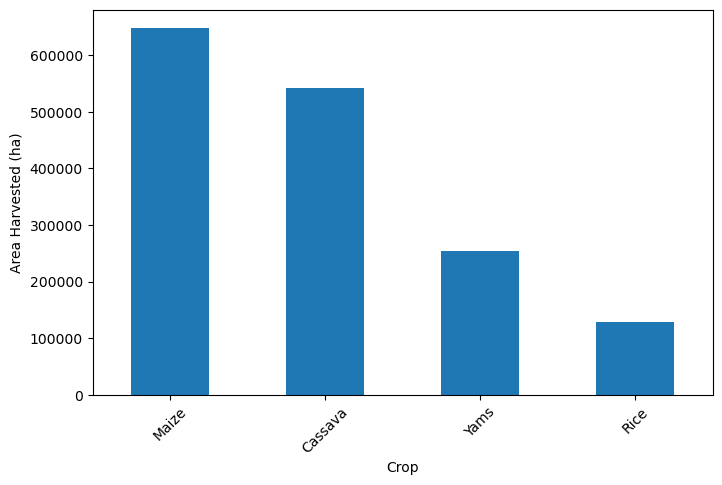

In [25]:
plt.figure(figsize=(8,5))

avg_area.plot(
    kind="bar"
)

plt.title("")
plt.xlabel("Crop")
plt.ylabel("Area Harvested (ha)")
plt.xticks(rotation=45)

plt.savefig(
    os.path.join(fig_path, "AVERAGE AREA HARVESTEDD BY CROP.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [8]:
#AVERAGE YIELD BY CROP
avg_yield = (
    df.groupby("crop")["Yield_kg_per_ha"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_yield)

crop
Cassava    12138.284375
Yams       10928.218750
Rice        1789.026562
Maize       1456.843750
Name: Yield_kg_per_ha, dtype: float64


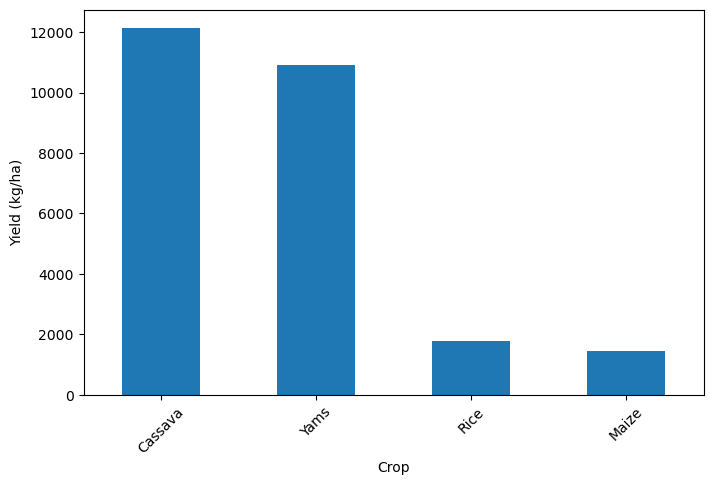

In [27]:
plt.figure(figsize=(8,5))

avg_yield.plot(
    kind="bar"
)

plt.title("")
plt.xlabel("Crop")
plt.ylabel("Yield (kg/ha)")
plt.xticks(rotation=45)
plt.savefig(
    os.path.join(fig_path, "Average Yield per crop.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

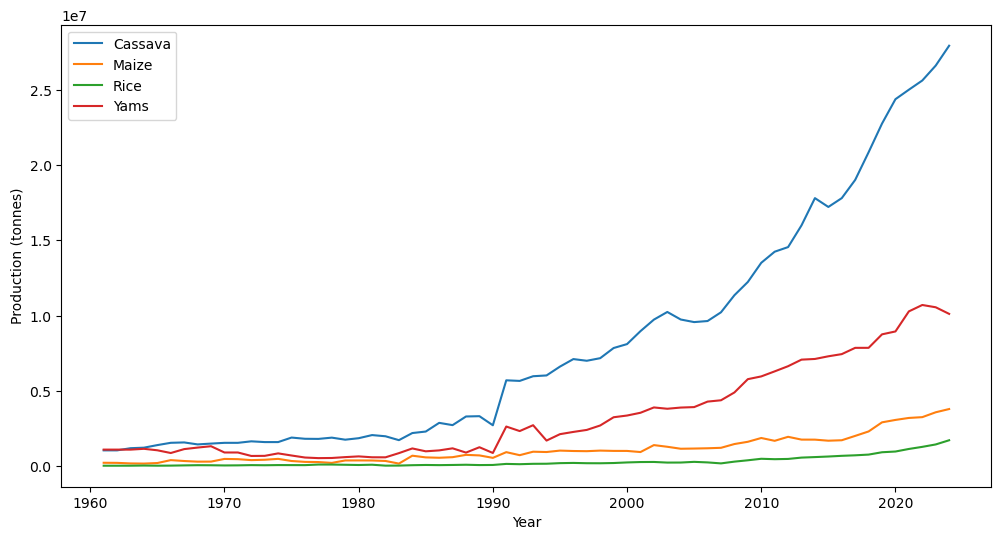

In [28]:
#PRODUCTION OVER TIME
plt.figure(figsize=(12,6))

for crop in df["crop"].unique():

    crop_data = df[df["crop"] == crop]

    plt.plot(
        crop_data["year"],
        crop_data["Production_tonnes"],
        label=crop
    )

plt.title("")
plt.xlabel("Year")
plt.ylabel("Production (tonnes)")
plt.legend()
plt.savefig(
    os.path.join(fig_path, "PRODUCTION TRENDS.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

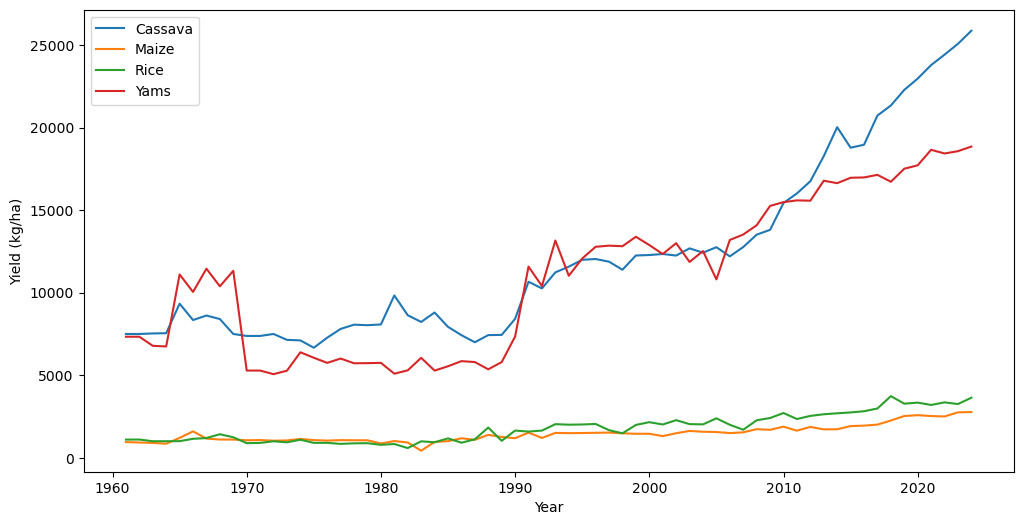

In [29]:
#YIELD OVER TIME
plt.figure(figsize=(12,6))

for crop in df["crop"].unique():

    crop_data = df[df["crop"] == crop]

    plt.plot(
        crop_data["year"],
        crop_data["Yield_kg_per_ha"],
        label=crop
    )

plt.title("")
plt.xlabel("Year")
plt.ylabel("Yield (kg/ha)")
plt.legend()
plt.savefig(
    os.path.join(fig_path, "YIELD TREND.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

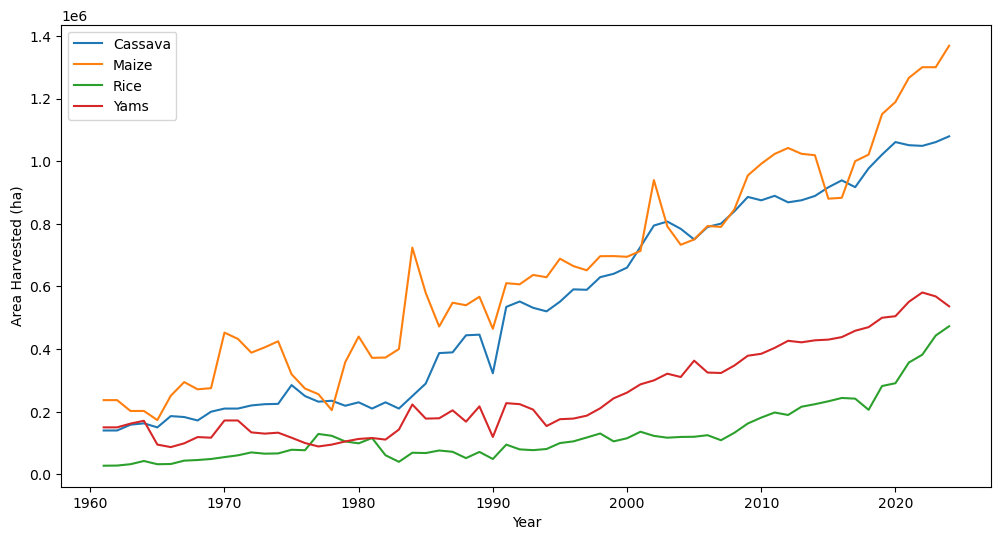

In [12]:
#AREA HARVESTED (PATTERN)
plt.figure(figsize=(12,6))

for crop in df["crop"].unique():

    crop_data = df[df["crop"] == crop]

    plt.plot(
        crop_data["year"],
        crop_data["Area_Harvested_ha"],
        label=crop
    )

plt.title("")
plt.xlabel("Year")
plt.ylabel("Area Harvested (ha)")
plt.legend()
plt.show()

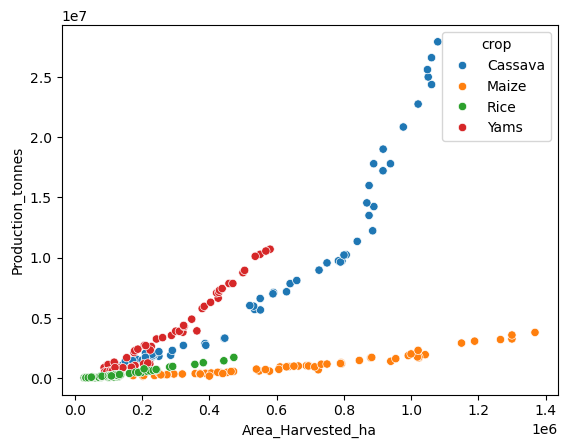

In [30]:
#PRODUCTION VS. AREA
sns.scatterplot(
    data=df,
    x="Area_Harvested_ha",
    y="Production_tonnes",
    hue="crop"
)

plt.title("")
plt.savefig(
    os.path.join(fig_path, "PRODUCTION VS AREA.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

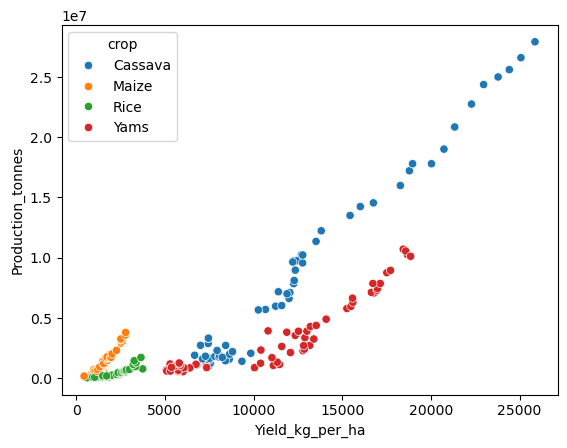

In [14]:
#PRODUCTION VS Yield
sns.scatterplot(
    data=df,
    x="Yield_kg_per_ha",
    y="Production_tonnes",
    hue="crop"
)

plt.title("")
plt.show()

In [15]:
#CORRELATION
correlation = df[
    [
        "Area_Harvested_ha",
        "Yield_kg_per_ha",
        "Production_tonnes"
    ]
].corr()

correlation

,Area_Harvested_ha,Yield_kg_per_ha,Production_tonnes
Area_Harvested_ha,1.000000,0.318151,0.598379
Yield_kg_per_ha,0.318151,1.000000,0.847542
Production_tonnes,0.598379,0.847542,1.000000


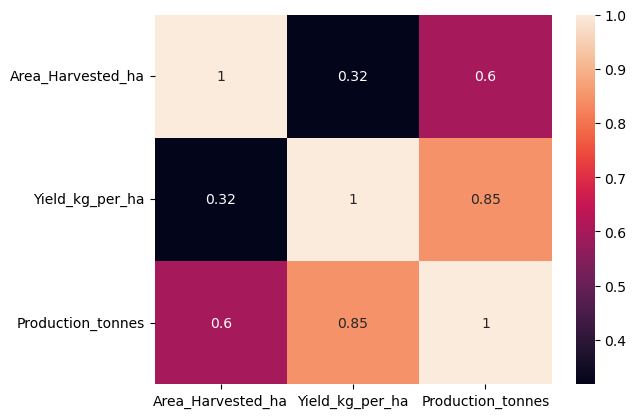

In [31]:
sns.heatmap(
    correlation,
    annot=True
)

plt.title("")
plt.savefig(
    os.path.join(fig_path, "CORRELATION.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()